# Generalized Collatz: The (x, y) Parameter Space

We generalize the Collatz map to the family $T(n) = (xn + y) / 2^{v_2(xn+y)}$ for odd $x$, odd $y$.

**Key insight**: The v-distribution is *universal* — $P(v=k) = 1/2^k$ for ALL odd $(x,y)$.
This means $E[v] = 2$ always, and the average shrinkage factor is $x/4$.

- $x < 4$: statistically convergent ($x=1,3$)
- $x > 4$: statistically divergent ($x=5,7,9,...$)
- $x = 3$ (Collatz): the **last convergent odd case**, sitting at the boundary

In [1]:
import os
import sys
from collections import Counter
from math import log2

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

In [2]:
def syracuse_general(n, x, y):
    """Syracuse map: odd n -> (xn + y) / 2^v."""
    val = x * n + y
    if val <= 0:
        return None, 0
    v = 0
    while val % 2 == 0:
        val //= 2
        v += 1
    return val, v


def trajectory_general(n, x, y, max_steps=2000):
    """Trajectory of odd n under the (x, y) Syracuse map."""
    values = [n]
    vs = []
    visited = {n: 0}
    for step in range(1, max_steps + 1):
        result, v = syracuse_general(n, x, y)
        if result is None:
            return values, vs, "non-positive"
        vs.append(v)
        if result in visited:
            values.append(result)
            return values, vs, "cycle"
        if result > n * 1000 and step > 50:
            values.append(result)
            return values, vs, "diverged"
        visited[result] = step
        values.append(result)
        n = result
    return values, vs, "diverged"


def find_cycles_general(x, y, max_start=5000, max_steps=5000):
    """Find all cycles for the (x, y) Syracuse map."""
    all_cycles = []
    cycle_members = set()
    for start in range(1, max_start, 2):
        if start in cycle_members:
            continue
        n = start
        visited = {}
        for step in range(max_steps):
            if n in visited:
                cycle = []
                m = n
                while True:
                    next_m, v = syracuse_general(m, x, y)
                    if next_m is None:
                        break
                    cycle.append((m, v))
                    m = next_m
                    if m == n:
                        break
                if cycle:
                    cycle_set = frozenset(e[0] for e in cycle)
                    if cycle_set not in [frozenset(e[0] for e in c) for c in all_cycles]:
                        all_cycles.append(cycle)
                        cycle_members.update(e[0] for e in cycle)
                break
            visited[n] = step
            next_n, v = syracuse_general(n, x, y)
            if next_n is None:
                break
            if next_n == 1 and x <= 3:
                break
            n = next_n
    return all_cycles

## 1. Phase Diagram: Convergence in (x, y) Space

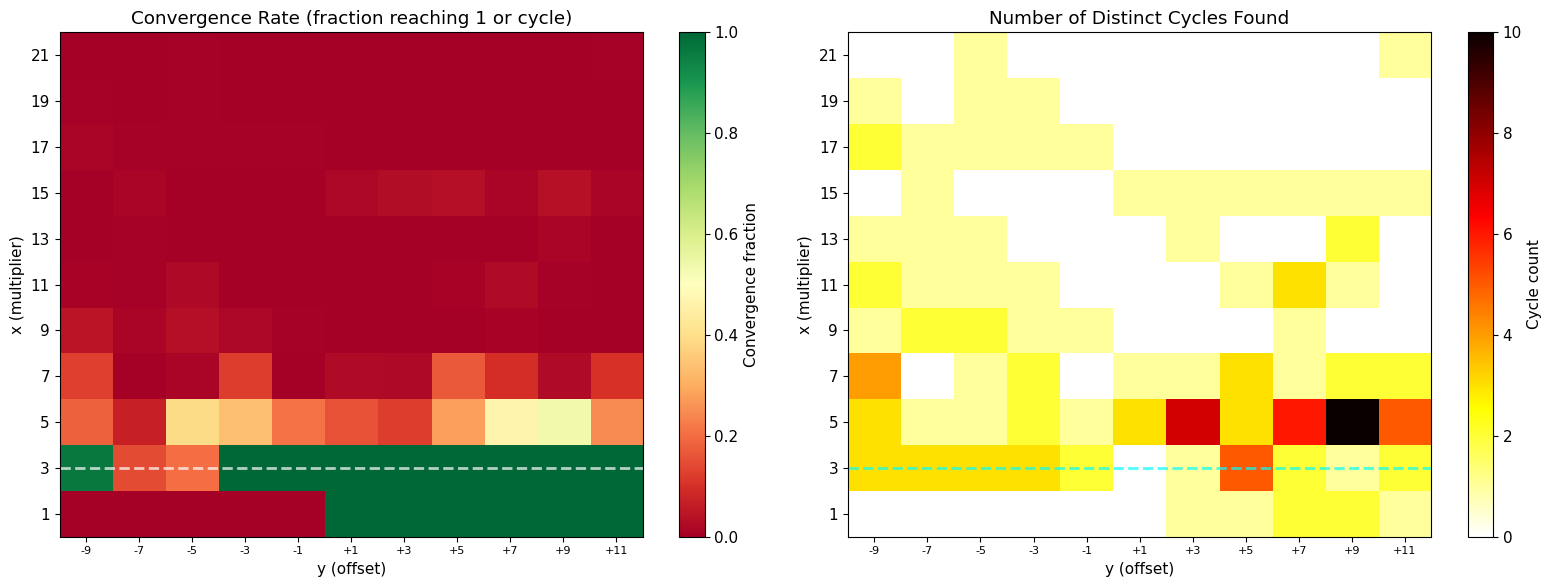

In [3]:
# Scan phase space
x_vals = list(range(1, 22, 2))  # odd x: 1, 3, 5, ..., 21
y_vals = list(range(-9, 12, 2))  # odd y: -9, -7, ..., 11

conv_grid = np.zeros((len(x_vals), len(y_vals)))
cycle_grid = np.zeros((len(x_vals), len(y_vals)))

for ix, x in enumerate(x_vals):
    for iy, y in enumerate(y_vals):
        outcomes = Counter()
        for n in range(3, 500, 2):
            if x * n + y <= 0:
                outcomes["non-positive"] += 1
                continue
            _, _, outcome = trajectory_general(n, x, y, max_steps=500)
            outcomes[outcome] += 1
        total = sum(outcomes.values())
        if total > 0:
            conv_grid[ix, iy] = (outcomes.get("converged", 0) + outcomes.get("cycle", 0)) / total
            # Count cycles
            cycles = find_cycles_general(x, y, max_start=1000, max_steps=1000)
            cycle_grid[ix, iy] = len(cycles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Convergence heatmap
im1 = ax1.imshow(conv_grid, aspect="auto", origin="lower", cmap="RdYlGn", vmin=0, vmax=1)
ax1.set_xticks(range(len(y_vals)))
ax1.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=8)
ax1.set_yticks(range(len(x_vals)))
ax1.set_yticklabels(x_vals)
ax1.set_xlabel("y (offset)")
ax1.set_ylabel("x (multiplier)")
ax1.set_title("Convergence Rate (fraction reaching 1 or cycle)")
ax1.axhline(y=1, color="white", linewidth=2, linestyle="--", alpha=0.7)  # x=3 row
plt.colorbar(im1, ax=ax1, label="Convergence fraction")

# Cycle count heatmap
im2 = ax2.imshow(cycle_grid, aspect="auto", origin="lower", cmap="hot_r", vmin=0)
ax2.set_xticks(range(len(y_vals)))
ax2.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=8)
ax2.set_yticks(range(len(x_vals)))
ax2.set_yticklabels(x_vals)
ax2.set_xlabel("y (offset)")
ax2.set_ylabel("x (multiplier)")
ax2.set_title("Number of Distinct Cycles Found")
ax2.axhline(y=1, color="cyan", linewidth=2, linestyle="--", alpha=0.7)
plt.colorbar(im2, ax=ax2, label="Cycle count")

plt.tight_layout()
plt.savefig("../analysis/phase_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. The Lyapunov Curve: Growth Rate vs x

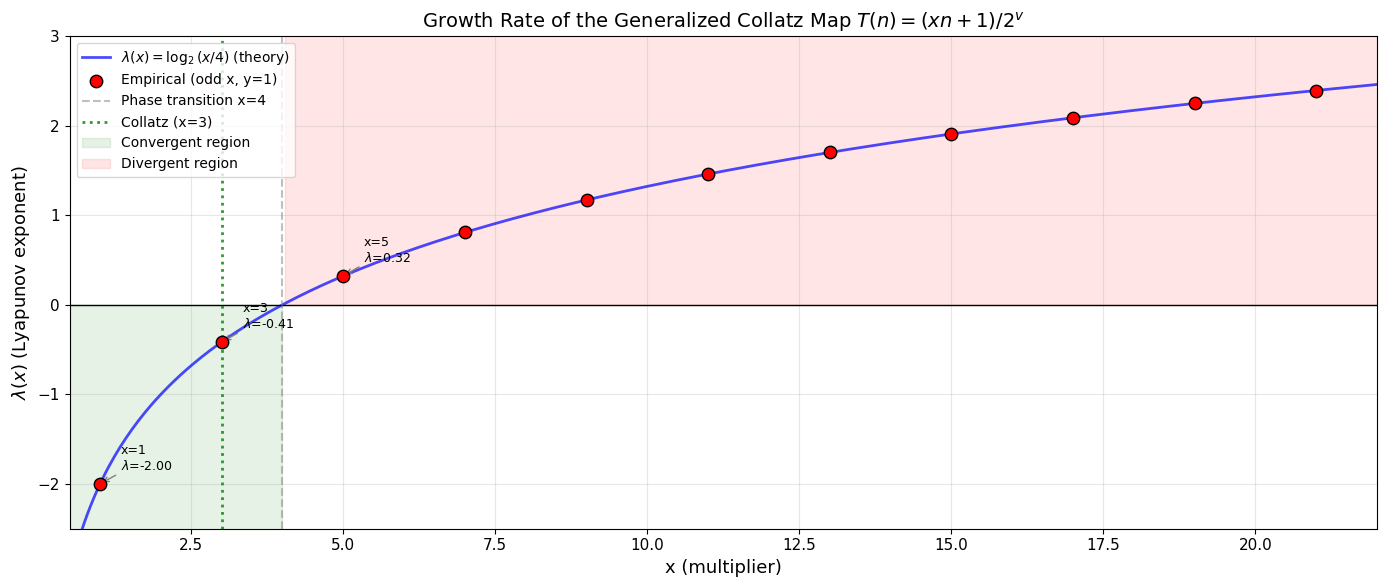

In [4]:
# Lyapunov exponent as function of x (continuous curve + empirical points)
x_continuous = np.linspace(0.5, 25, 500)
lambda_theory = np.log2(x_continuous / 4)

# Empirical points
x_empirical = list(range(1, 22, 2))
lambda_empirical = []
for x in x_empirical:
    ratios = []
    for n in range(3, 10001, 2):
        result, v = syracuse_general(n, x, 1)
        if result is not None and result > 0:
            ratios.append(log2(result / n))
    lambda_empirical.append(np.mean(ratios))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    x_continuous,
    lambda_theory,
    "b-",
    linewidth=2,
    label=r"$\lambda(x) = \log_2(x/4)$ (theory)",
    alpha=0.7,
)
ax.scatter(
    x_empirical,
    lambda_empirical,
    c="red",
    s=80,
    zorder=5,
    label="Empirical (odd x, y=1)",
    edgecolors="black",
)
ax.axhline(y=0, color="black", linewidth=1, linestyle="-")
ax.axvline(
    x=4, color="gray", linewidth=1.5, linestyle="--", alpha=0.5, label="Phase transition x=4"
)
ax.axvline(x=3, color="green", linewidth=2, linestyle=":", alpha=0.8, label="Collatz (x=3)")

# Shade convergent region
ax.fill_between(
    x_continuous,
    -3,
    0,
    where=(x_continuous < 4),
    alpha=0.1,
    color="green",
    label="Convergent region",
)
ax.fill_between(
    x_continuous, 0, 5, where=(x_continuous > 4), alpha=0.1, color="red", label="Divergent region"
)

ax.set_xlabel("x (multiplier)", fontsize=13)
ax.set_ylabel(r"$\lambda(x)$ (Lyapunov exponent)", fontsize=13)
ax.set_title("Growth Rate of the Generalized Collatz Map $T(n) = (xn+1)/2^v$", fontsize=14)
ax.set_xlim(0.5, 22)
ax.set_ylim(-2.5, 3)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate key points
for x, lam in zip(x_empirical, lambda_empirical, strict=False):
    if x in [1, 3, 5]:
        ax.annotate(
            f"x={x}\n$\\lambda$={lam:.2f}",
            (x, lam),
            textcoords="offset points",
            xytext=(15, 10),
            fontsize=9,
            arrowprops={"arrowstyle": "->", "color": "gray"},
        )

plt.tight_layout()
plt.savefig("../analysis/lyapunov_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Convergence Cliff: $\mu(x)$ drops from 100% to near 0%

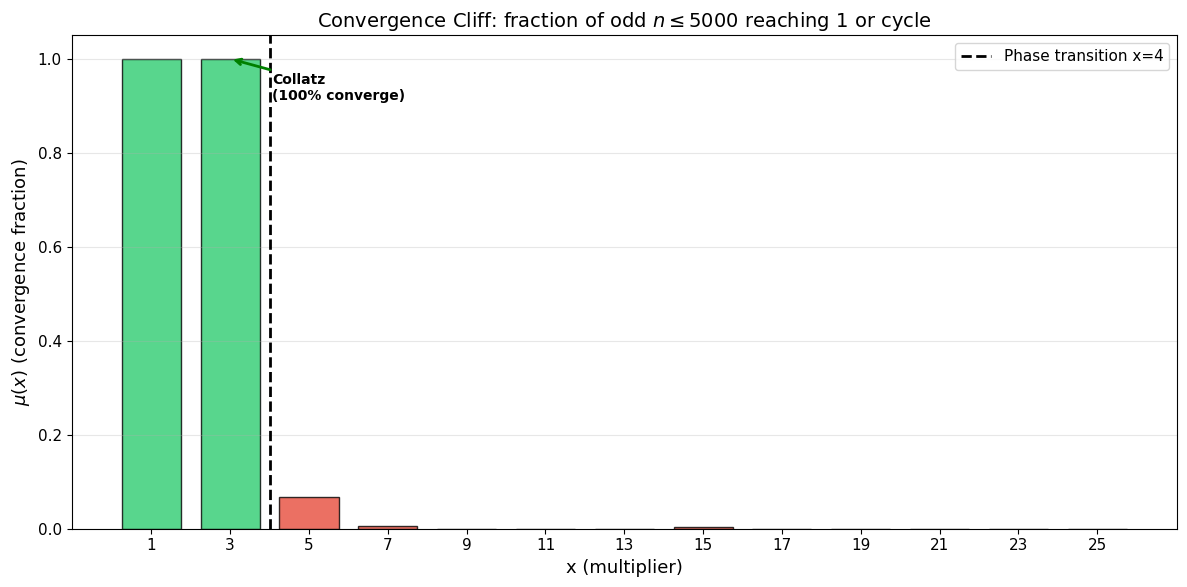

In [5]:
# Convergence measure for finer grid of x values
x_range = list(range(1, 26, 2))
mu_values = []

for x in x_range:
    conv = 0
    total = 0
    for n in range(3, 5001, 2):
        _, _, outcome = trajectory_general(n, x, 1, max_steps=500)
        total += 1
        if outcome in ("converged", "cycle"):
            conv += 1
    mu_values.append(conv / total)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ecc71" if x < 4 else "#e74c3c" for x in x_range]
bars = ax.bar(x_range, mu_values, width=1.5, color=colors, edgecolor="black", alpha=0.8)
ax.axvline(x=4, color="black", linewidth=2, linestyle="--", label="Phase transition x=4")
ax.set_xlabel("x (multiplier)", fontsize=13)
ax.set_ylabel(r"$\mu(x)$ (convergence fraction)", fontsize=13)
ax.set_title(r"Convergence Cliff: fraction of odd $n \leq 5000$ reaching 1 or cycle", fontsize=14)
ax.set_xticks(x_range)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# Annotate Collatz
ax.annotate(
    "Collatz\n(100% converge)",
    (3, 1.0),
    textcoords="offset points",
    xytext=(30, -30),
    fontsize=10,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": "green", "lw": 2},
)

plt.tight_layout()
plt.savefig("../analysis/convergence_cliff.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. v-Distribution Universality

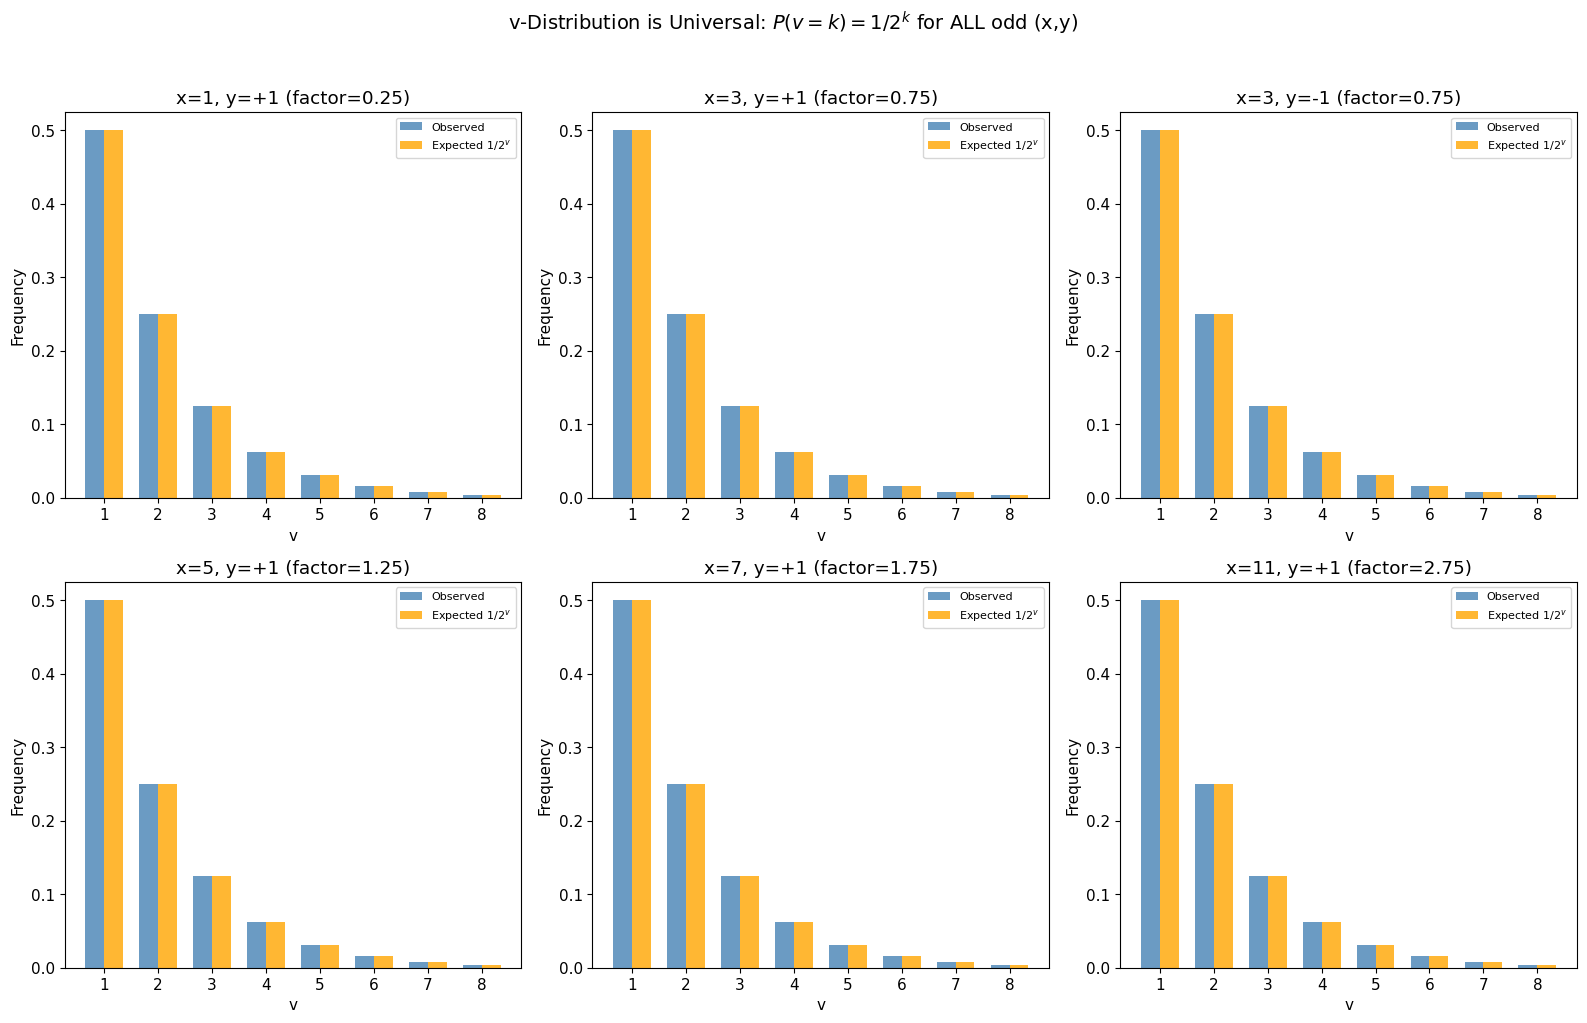

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (x, y) in enumerate([(1, 1), (3, 1), (3, -1), (5, 1), (7, 1), (11, 1)]):
    v_counts = Counter()
    total = 0
    for n in range(1, 20000, 2):
        val = x * n + y
        if val <= 0:
            continue
        v = 0
        while val % 2 == 0:
            val //= 2
            v += 1
        if v >= 1:
            v_counts[v] += 1
            total += 1

    ax = axes[idx]
    vs = list(range(1, 9))
    observed = [v_counts.get(v, 0) / total for v in vs]
    expected = [1 / 2**v for v in vs]

    width = 0.35
    ax.bar(
        [v - width / 2 for v in vs], observed, width, label="Observed", color="steelblue", alpha=0.8
    )
    ax.bar(
        [v + width / 2 for v in vs],
        expected,
        width,
        label="Expected $1/2^v$",
        color="orange",
        alpha=0.8,
    )
    ax.set_xlabel("v")
    ax.set_ylabel("Frequency")
    ax.set_title(f"x={x}, y={y:+d} (factor={x / 4:.2f})")
    ax.legend(fontsize=8)
    ax.set_xticks(vs)

plt.suptitle("v-Distribution is Universal: $P(v=k) = 1/2^k$ for ALL odd (x,y)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../analysis/v_universality.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Diophantine Landscape: Close Approaches of $2^s$ to $x^k$

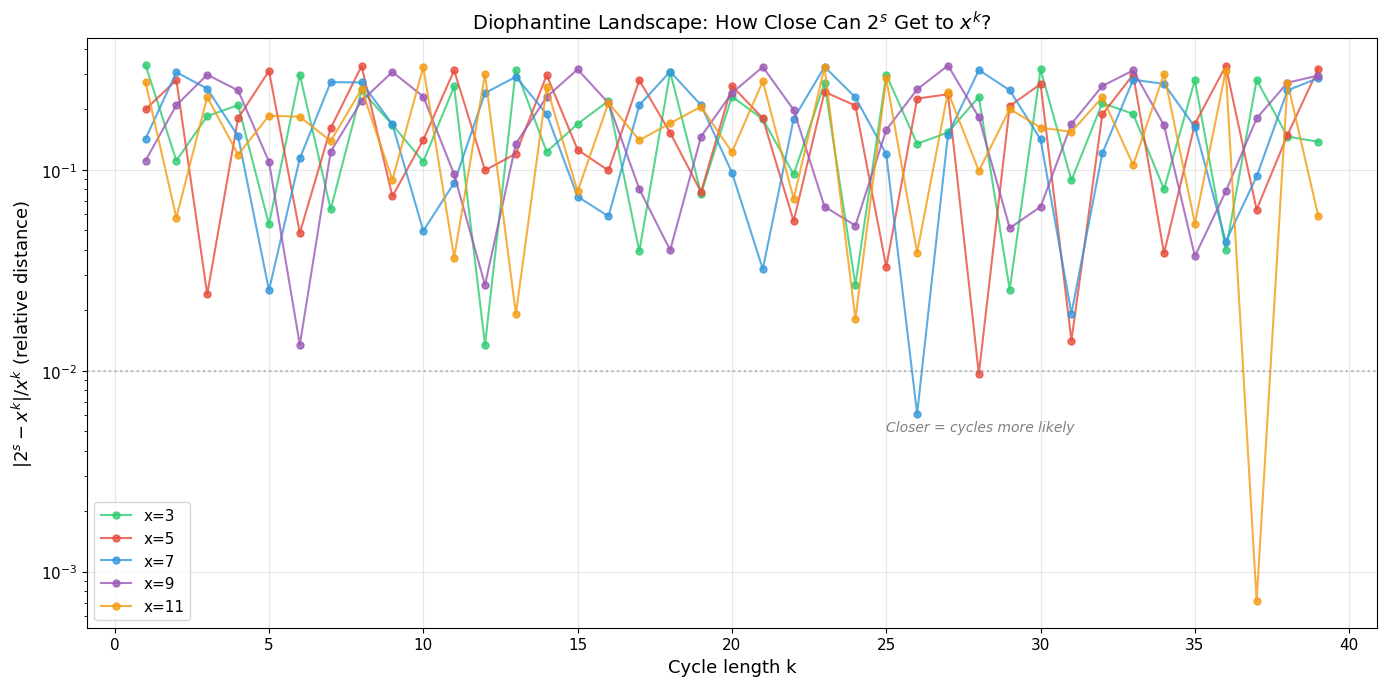

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

colors_map = {3: "#2ecc71", 5: "#e74c3c", 7: "#3498db", 9: "#9b59b6", 11: "#f39c12"}

for x in [3, 5, 7, 9, 11]:
    ks = []
    rel_dists = []
    for k in range(1, 40):
        s_approx = k * log2(x)
        # Pick the closer of floor and ceil
        s_lo = int(s_approx)
        s_hi = s_lo + 1
        diff_lo = abs(2**s_lo - x**k)
        diff_hi = abs(2**s_hi - x**k)
        best_diff = diff_lo if diff_lo < diff_hi else diff_hi
        rel = best_diff / x**k
        ks.append(k)
        rel_dists.append(rel)

    ax.semilogy(ks, rel_dists, "o-", color=colors_map[x], label=f"x={x}", markersize=5, alpha=0.8)

ax.set_xlabel("Cycle length k", fontsize=13)
ax.set_ylabel(r"$|2^s - x^k| / x^k$ (relative distance)", fontsize=13)
ax.set_title("Diophantine Landscape: How Close Can $2^s$ Get to $x^k$?", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.01, color="gray", linestyle=":", alpha=0.5)
ax.annotate(
    "Closer = cycles more likely", (25, 0.005), fontsize=10, fontstyle="italic", color="gray"
)

plt.tight_layout()
plt.savefig("../analysis/diophantine_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Mod-x Bias: What "+1" Does at Each Multiplier

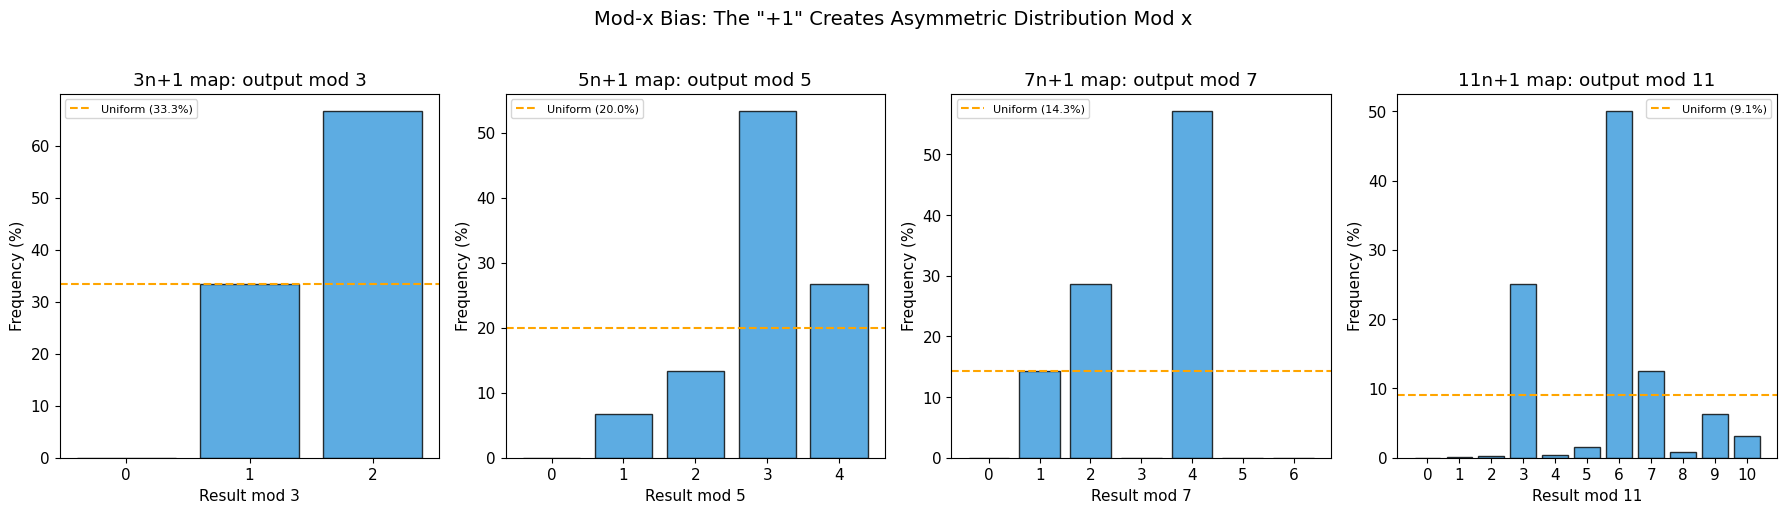

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, x in enumerate([3, 5, 7, 11]):
    dist = Counter()
    total = 0
    for n in range(1, 30000, 2):
        result, v = syracuse_general(n, x, 1)
        if result is not None:
            dist[result % x] += 1
            total += 1

    ax = axes[idx]
    residues = list(range(x))
    freqs = [dist.get(r, 0) / total * 100 for r in residues]
    uniform = 100 / x

    bars = ax.bar(
        residues,
        freqs,
        color=["#e74c3c" if f == 0 else "#3498db" for f in freqs],
        edgecolor="black",
        alpha=0.8,
    )
    ax.axhline(
        y=uniform, color="orange", linestyle="--", linewidth=1.5, label=f"Uniform ({uniform:.1f}%)"
    )
    ax.set_xlabel(f"Result mod {x}")
    ax.set_ylabel("Frequency (%)")
    ax.set_title(f"{x}n+1 map: output mod {x}")
    ax.set_xticks(residues)
    ax.legend(fontsize=8)

plt.suptitle('Mod-x Bias: The "+1" Creates Asymmetric Distribution Mod x', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../analysis/mod_x_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sample Trajectories Across the Phase Boundary

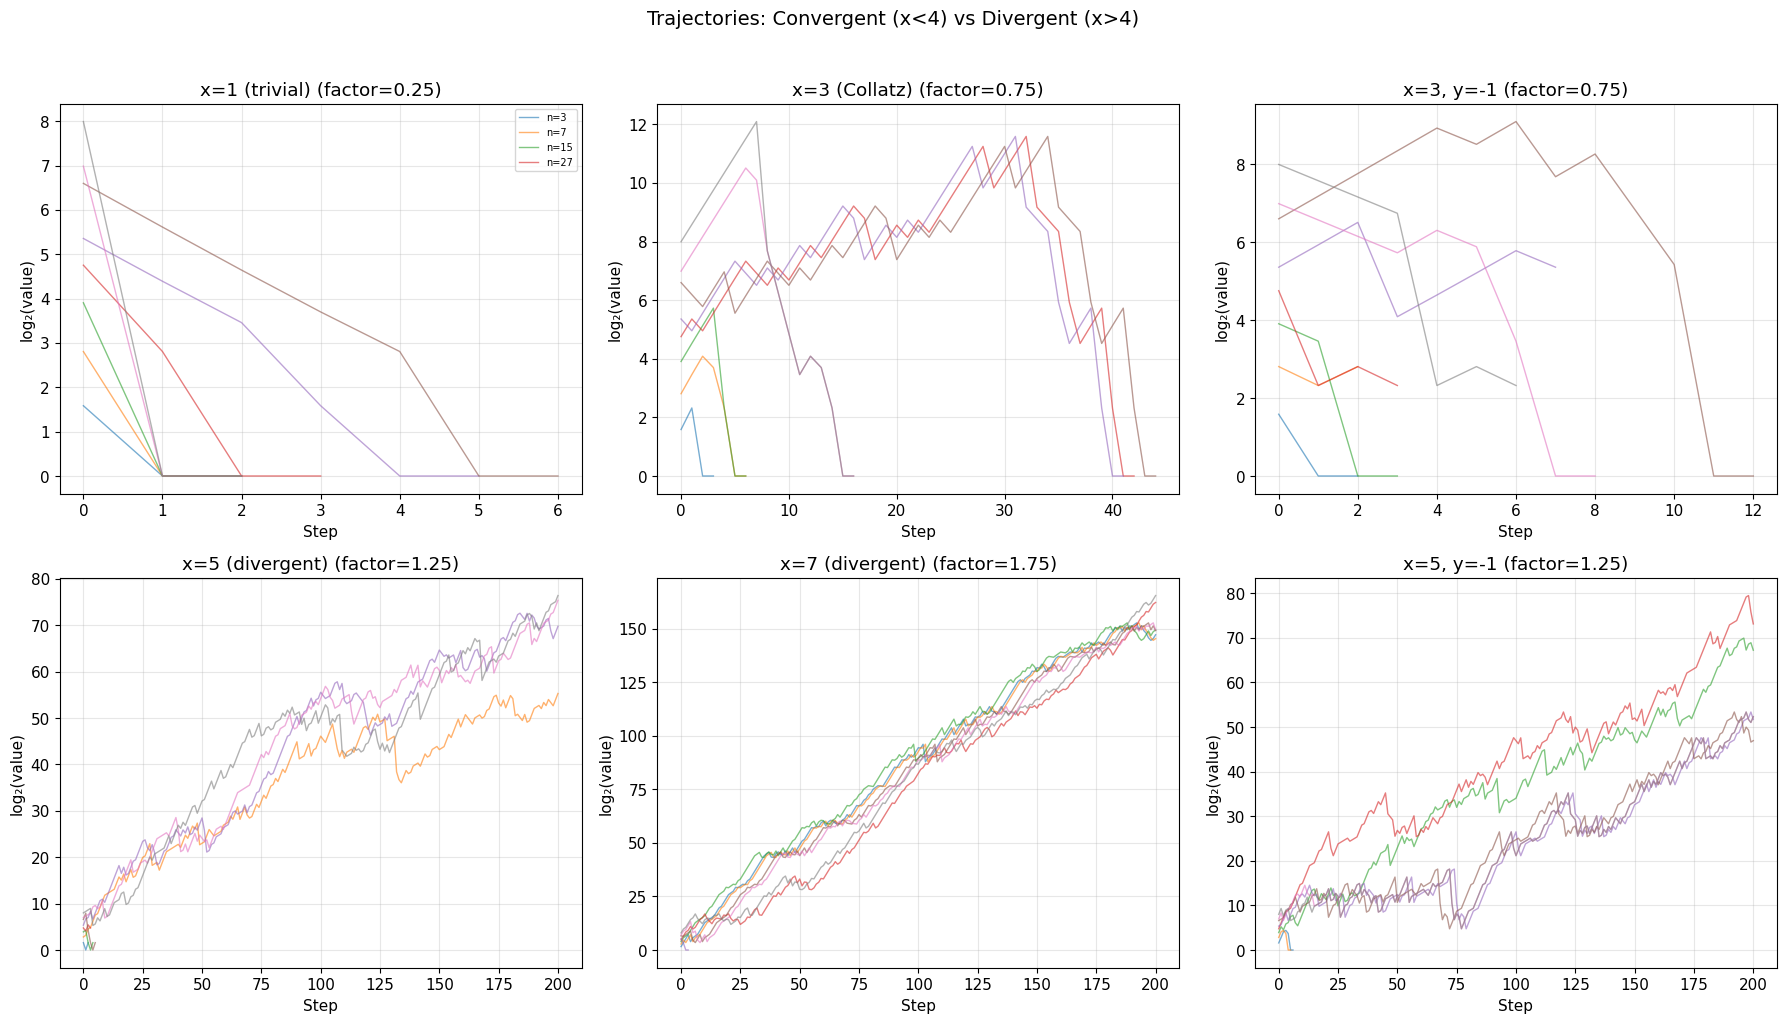

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cases = [
    (1, 1, "x=1 (trivial)"),
    (3, 1, "x=3 (Collatz)"),
    (3, -1, "x=3, y=-1"),
    (5, 1, "x=5 (divergent)"),
    (7, 1, "x=7 (divergent)"),
    (5, -1, "x=5, y=-1"),
]

for idx, (x, y, title) in enumerate(cases):
    ax = axes.flatten()[idx]
    for n in [3, 7, 15, 27, 41, 97, 127, 255]:
        vals, vs, outcome = trajectory_general(n, x, y, max_steps=200)
        ax.plot(
            range(len(vals)),
            np.log2(np.array(vals, dtype=float).clip(1)),
            alpha=0.6,
            linewidth=1,
            label=f"n={n}" if n <= 27 else None,
        )

    ax.set_xlabel("Step")
    ax.set_ylabel("log₂(value)")
    ax.set_title(f"{title} (factor={x / 4:.2f})")
    if idx == 0:
        ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Trajectories: Convergent (x<4) vs Divergent (x>4)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../analysis/trajectories_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. The Cycle Equation: $n = C / (2^s - x^k)$

For +y maps: C > 0, need $2^s > x^k$ (shrinking cycle).
For -y maps: C < 0, need $2^s < x^k$ (growing cycle).

The close approaches of $2^s$ to $x^k$ are governed by the continued fraction expansion of $\log_2(x)$.

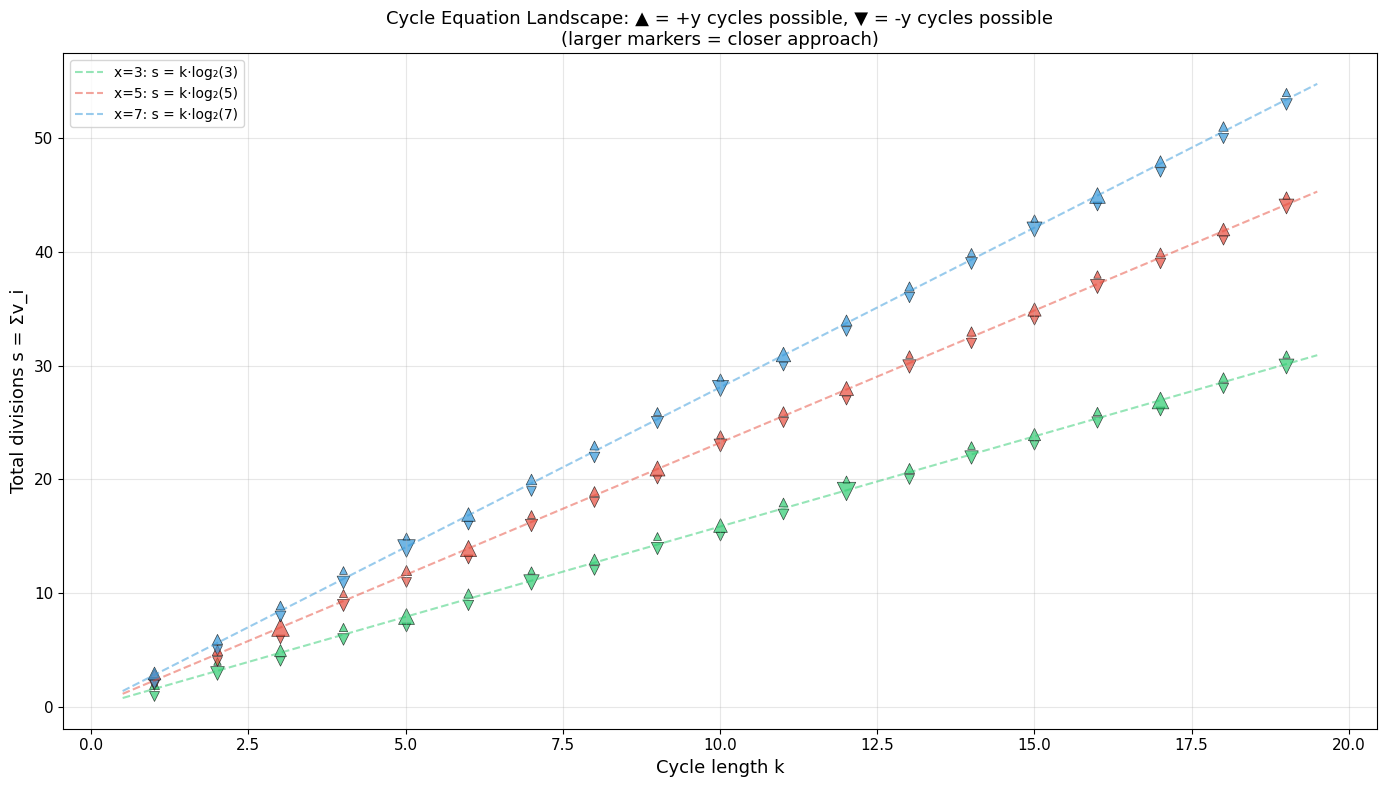

In [10]:
# Visualize 2^s vs x^k for different x values
fig, ax = plt.subplots(figsize=(14, 8))

for x, color in [(3, "#2ecc71"), (5, "#e74c3c"), (7, "#3498db")]:
    ks = list(range(1, 20))
    for k in ks:
        s_lo = int(k * log2(x))
        s_hi = s_lo + 1
        # Plot points where 2^s is close to x^k
        for s in [s_lo, s_hi]:
            diff = 2**s - x**k
            marker = "^" if diff > 0 else "v"
            size = max(10, 200 / (1 + np.log1p(abs(diff) / x**k) * 10))
            ax.scatter(
                k, s, c=color, s=size, marker=marker, alpha=0.7, edgecolors="black", linewidth=0.5
            )

    # Reference line: s = k * log2(x)
    k_line = np.linspace(0.5, 19.5, 100)
    ax.plot(k_line, k_line * log2(x), "--", color=color, alpha=0.5, label=f"x={x}: s = k·log₂({x})")

ax.set_xlabel("Cycle length k", fontsize=13)
ax.set_ylabel("Total divisions s = Σv_i", fontsize=13)
ax.set_title(
    "Cycle Equation Landscape: ▲ = +y cycles possible, ▼ = -y cycles possible\n(larger markers = closer approach)",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../analysis/cycle_equation.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

The generalized Collatz family $T(n) = (xn+y)/2^v$ reveals:

1. **Universal statistics**: $P(v=k) = 1/2^k$, $E[v] = 2$ for all odd $(x,y)$
2. **Phase transition at x=4**: Collatz ($x=3$) is the *last convergent odd case*
3. **Cycle existence**: Governed by Diophantine approximation of $\log_2(x)$ via Baker's theorem
4. **The +1 effect**: Creates an x-adic bias that determines which sign of $2^s - x^k$ allows cycles
5. **Analytic structure**: $\lambda(x) = \log_2(x/4)$ is smooth through the phase boundary

The key question for spectral continuation: is there a function $F(z)$ defined in the divergent region that extends to $z=3$ and whose value there encodes the Collatz conjecture?